In [1]:
pip install polars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 77.2 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.7/109.7 kB 23.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 103.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 105.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 96.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 106.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 kB 67.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
import polars as pl

In [50]:
import polars as pl
import matplotlib.pyplot as plt

schema = pl.Schema({"Timers":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})
formats = [720,1080,2160]
ylimits=[1,2,4]
data_h2h_wait_ofi = {}
data_h2h_spin_ofi = {}
data_d2d_wait_ofi = {}
data_d2d_spin_ofi = {}
data_h2h_wait_native = {}
data_h2h_spin_native = {}
data_d2d_wait_native = {}
data_d2d_spin_native = {}
for img_size in formats:
    data_d2d_wait_ofi[img_size] = pl.read_csv(f"../data/verbs/gpu-max-clock/{img_size}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+Wait.csv",schema=schema).select(pl.col("Timers"))
    data_d2d_spin_ofi[img_size] = pl.read_csv(f"../data/verbs/gpu-max-clock/{img_size}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+Spin.csv",schema=schema).select(pl.col("Timers"))
    data_h2h_wait_ofi[img_size] = pl.read_csv(f"../data/verbs/gpu-max-clock/{img_size}/MXLFabrics+Host2Host+Verbs+Reflect+Wait.csv",schema=schema).select(pl.col("Timers"))
    data_h2h_spin_ofi[img_size] = pl.read_csv(f"../data/verbs/gpu-max-clock/{img_size}/MXLFabrics+Host2Host+Verbs+Reflect+Spin.csv",schema=schema).select(pl.col("Timers"))
    data_d2d_wait_native[img_size] = pl.read_csv(f"../output/h2h-vs-c2c-data/test-{img_size}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+Wait.csv",schema=schema).select(pl.col("Timers"))
    data_d2d_spin_native[img_size] = pl.read_csv(f"../output/h2h-vs-c2c-data/test-{img_size}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+Spin.csv",schema=schema).select(pl.col("Timers"))
    data_h2h_wait_native[img_size] = pl.read_csv(f"../output/h2h-vs-c2c-data/test-{img_size}/MXLFabrics+Host2Host+Verbs+Reflect+Wait.csv",schema=schema).select(pl.col("Timers"))
    data_h2h_spin_native[img_size] = pl.read_csv(f"../output/h2h-vs-c2c-data/test-{img_size}/MXLFabrics+Host2Host+Verbs+Reflect+Spin.csv",schema=schema).select(pl.col("Timers"))
plt.rcParams['figure.figsize'] = [14,8]

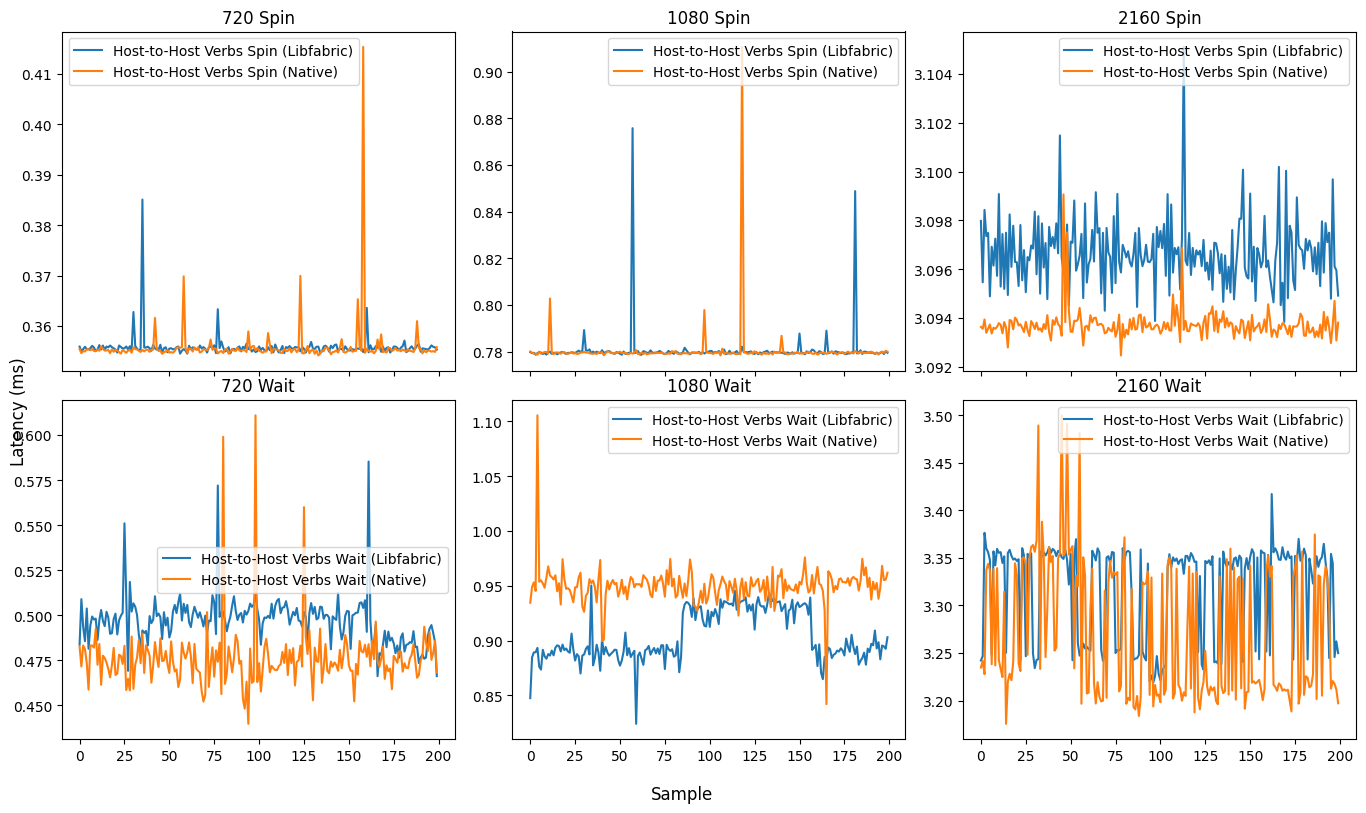

In [53]:
fig, axs = plt.subplots(nrows=2,ncols=len(formats), sharex=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")

fig.tight_layout()
for i, img_size in enumerate(formats):
    axs[0][i].set_title(f"{img_size} Spin")
    axs[0][i].plot(data_h2h_spin_ofi[img_size]/1e6/2, label=f"Host-to-Host Verbs Spin (Libfabric)")
    axs[0][i].plot(data_h2h_spin_native[img_size]/1e6/2, label=f"Host-to-Host Verbs Spin (Native)")
    axs[0][i].legend()

    axs[1][i].set_title(f"{img_size} Wait")
    axs[1][i].plot(data_h2h_wait_ofi[img_size]/1e6/2, label=f"Host-to-Host Verbs Wait (Libfabric)")
    axs[1][i].plot(data_h2h_wait_native[img_size]/1e6/2, label=f"Host-to-Host Verbs Wait (Native)")
    axs[1][i].legend()


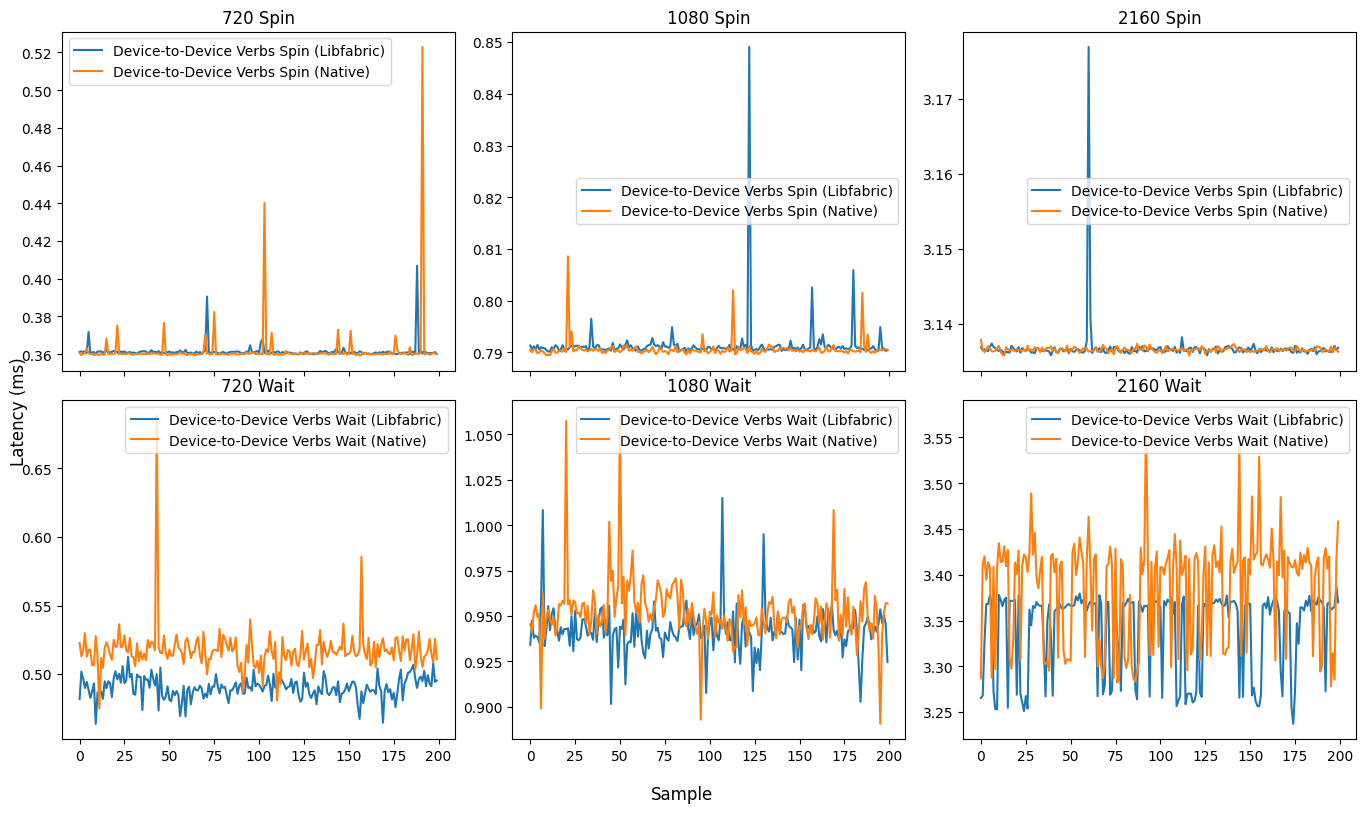

In [54]:
fig, axs = plt.subplots(nrows=2,ncols=len(formats), sharex=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")

fig.tight_layout()
for i, img_size in enumerate(formats):
    axs[0][i].set_title(f"{img_size} Spin")
    axs[0][i].plot(data_d2d_spin_ofi[img_size]/1e6/2, label=f"Device-to-Device Verbs Spin (Libfabric)")
    axs[0][i].plot(data_d2d_spin_native[img_size]/1e6/2, label=f"Device-to-Device Verbs Spin (Native)")
    axs[0][i].legend()

    axs[1][i].set_title(f"{img_size} Wait")
    axs[1][i].plot(data_d2d_wait_ofi[img_size]/1e6/2, label=f"Device-to-Device Verbs Wait (Libfabric)")
    axs[1][i].plot(data_d2d_wait_native[img_size]/1e6/2, label=f"Device-to-Device Verbs Wait (Native)")
    axs[1][i].legend()